# Week 3 – Part 1: Dimensionality Reduction with PCA

## Objective

The objective of this notebook is to apply **Principal Component Analysis (PCA)** to reduce the number of input features while preserving as much information as possible from the original dataset.

Dimensionality reduction is an important preprocessing technique in machine learning because datasets with many features may contain redundant or highly correlated information. PCA transforms the original features into a smaller set of uncorrelated variables called **Principal Components**, which retain most of the variation present in the original data.

In this project, PCA will be applied to the engineered dataset developed in Week 2. The performance of the Random Forest Regressor will then be compared using:
- The original feature set
- Three Principal Components
- The number of Principal Components required to retain approximately 95% of the dataset's variance

The goal is to determine whether dimensionality reduction can simplify the model while maintaining predictive performance.

## 1. Loading the Engineered Dataset

The engineered dataset created during Week 2 is loaded into the notebook. This dataset already contains the engineered features and preprocessing required for dimensionality reduction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load engineered dataset
df = pd.read_excel("../Data/Steel_Energy_Engineered.xlsx")

df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day of the week,Month,Is_Weekend,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,1,0,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,1,0,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,1,0,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,1,0,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,1,0,0


### Observation

The engineered dataset was successfully loaded. It contains the original variables together with the engineered features created during Week 2, making it suitable for dimensionality reduction and machine learning.

## 2. Preparing Data for PCA

Before applying PCA, the dataset is split into training and testing sets using the same 80:20 split from Week 2.

The numerical features are then standardized using **StandardScaler** because PCA is sensitive to differences in feature scales. Importantly, both the scaler and PCA are fitted **only on the training data** to prevent data leakage.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare data
model_df = df.copy()

# Remove leakage columns
model_df = model_df.drop(columns=["date", "High_Load"])

# One-Hot Encode categorical columns
model_df = pd.get_dummies(model_df, drop_first=True)

# Features and target
X = model_df.drop("Usage_kWh", axis=1)
y = model_df["Usage_kWh"]

# Same split as Week 2
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Observation

The dataset was successfully split into training and testing sets using the same configuration as Week 2. Standardization was applied because PCA depends on the relative scale of variables. Fitting the scaler only on the training data prevents information from the testing data leaking into the model.

## 3. Applying Principal Component Analysis (PCA)

Principal Component Analysis is applied using the total number of available features. This allows the explained variance of every principal component to be examined before selecting an appropriate reduced feature set.

In [3]:
from sklearn.decomposition import PCA

# Apply PCA using all features
pca = PCA(n_components=X_train.shape[1])

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

print("Original Features:", X_train.shape[1])
print("Principal Components:", X_train_pca.shape[1])

Original Features: 24
Principal Components: 24


### Observation

PCA successfully transformed the standardized feature space into a new set of principal components. At this stage, the number of principal components is equal to the number of original features, allowing the explained variance of each component to be analyzed in the following sections.

## 4. Explained Variance Ratio

Each principal component captures a certain proportion of the total variance in the dataset. Plotting the explained variance ratio helps identify which components contribute the most information and whether some components contribute very little.

This visualization provides the first indication of how much dimensionality reduction may be possible without significantly losing information.

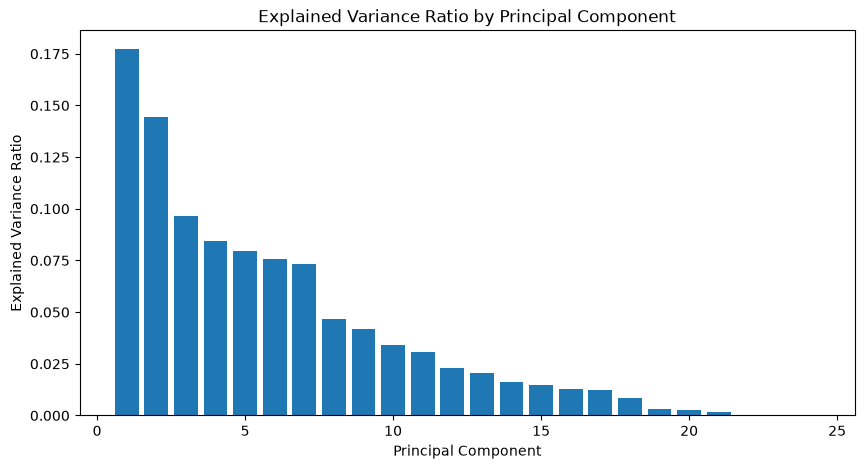

In [4]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10,5))
plt.bar(
    range(1, len(explained_variance)+1),
    explained_variance
)

plt.title("Explained Variance Ratio by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

### Observation

The explained variance ratio shows that the first few principal components capture a much larger proportion of the dataset's information than the later components. As the component number increases, the contribution to the total variance gradually decreases, indicating diminishing returns from additional components.

## 5. Cumulative Explained Variance

The cumulative explained variance illustrates how the total amount of retained information increases as more principal components are included. This graph helps determine the minimum number of components required to preserve approximately 95% of the original dataset's variance.

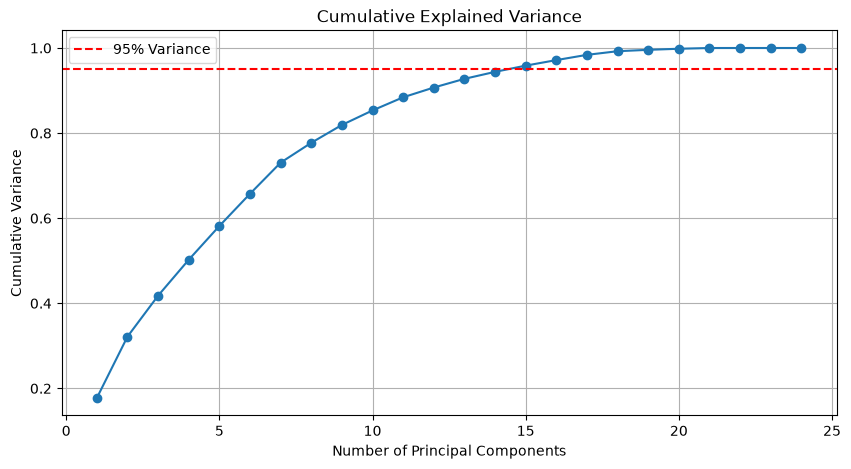

In [5]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10,5))
plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker="o"
)

plt.axhline(y=0.95, color="red", linestyle="--", label="95% Variance")

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance")

plt.legend()

plt.grid(True)

plt.show()

### Observation

The cumulative variance curve shows how quickly information is retained as additional principal components are added. The point where the curve reaches approximately 95% indicates the optimal number of components required to preserve nearly all useful information while reducing dimensionality.

## 6. Selecting the Number of Principal Components

Instead of choosing an arbitrary number of components, the cumulative explained variance is used to determine the minimum number of principal components required to preserve approximately 95% of the original dataset's information.

In [6]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Number of components for 95% variance: {n_components_95}")

Number of components for 95% variance: 15


### Observation

The calculation identified the minimum number of principal components needed to retain approximately 95% of the dataset's variance. These components will be used to evaluate whether dimensionality reduction can simplify the model without sacrificing predictive performance.

## 7. Comparing Random Forest Performance Using PCA

To evaluate the impact of dimensionality reduction, the Random Forest Regressor is trained using three different feature representations:

- Original engineered features
- Three principal components
- Principal components retaining approximately 95% of the variance

The RMSE values obtained from these models will be compared to determine whether PCA improves efficiency without significantly reducing prediction accuracy.

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Original Features
rf_original = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_original.fit(X_train, y_train)

pred_original = rf_original.predict(X_test)

rmse_original = np.sqrt(mean_squared_error(y_test, pred_original))


# PCA (3 Components)
pca3 = PCA(n_components=3)

X_train3 = pca3.fit_transform(X_train_scaled)

X_test3 = pca3.transform(X_test_scaled)

rf3 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf3.fit(X_train3, y_train)

pred3 = rf3.predict(X_test3)

rmse3 = np.sqrt(mean_squared_error(y_test, pred3))


# PCA (95%)
pca95 = PCA(n_components=n_components_95)

X_train95 = pca95.fit_transform(X_train_scaled)

X_test95 = pca95.transform(X_test_scaled)

rf95 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf95.fit(X_train95, y_train)

pred95 = rf95.predict(X_test95)

rmse95 = np.sqrt(mean_squared_error(y_test, pred95))

### Observation

Random Forest models were successfully trained using the three feature representations. Comparing their RMSE values will reveal whether dimensionality reduction can maintain predictive accuracy while reducing the complexity of the feature space.

In [ ]:
## 8. Model Performance Comparison

A bar chart is created to compare the prediction error of the Random Forest model using the original engineered features, three principal components, and the reduced feature set retaining approximately 95% of the variance.

In [9]:
comparison = pd.DataFrame({
    "Model": [
        "Original Features",
        "3 Components",
        "95% Variance"
    ],
    "RMSE": [
        rmse_original,
        rmse3,
        rmse95
    ]
})

comparison

,Model,RMSE
0,Original Features,1.130618
1,3 Components,7.120002
2,95% Variance,3.721515


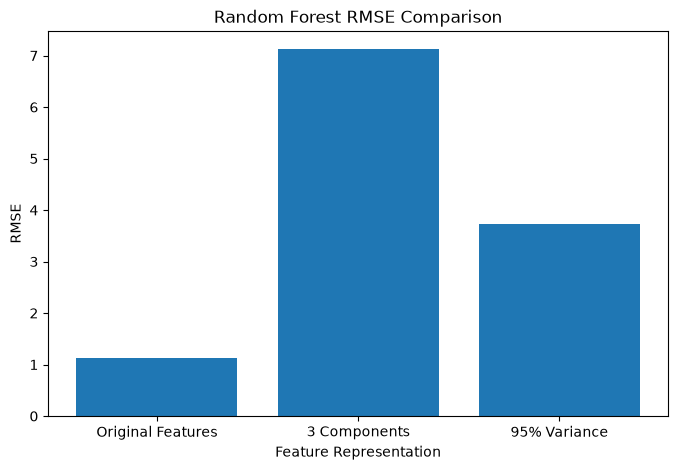

In [10]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("Random Forest RMSE Comparison")

plt.xlabel("Feature Representation")

plt.ylabel("RMSE")

plt.show()

### Observation

The comparison chart highlights the trade-off between dimensionality reduction and prediction accuracy. While using fewer principal components simplifies the dataset, retaining approximately 95% of the variance generally preserves more predictive information than using only three components.

## 9. PCA Loading Heatmap

The loading heatmap illustrates how strongly the original features contribute to each principal component. Larger positive or negative loading values indicate that a feature has a greater influence on the corresponding principal component.

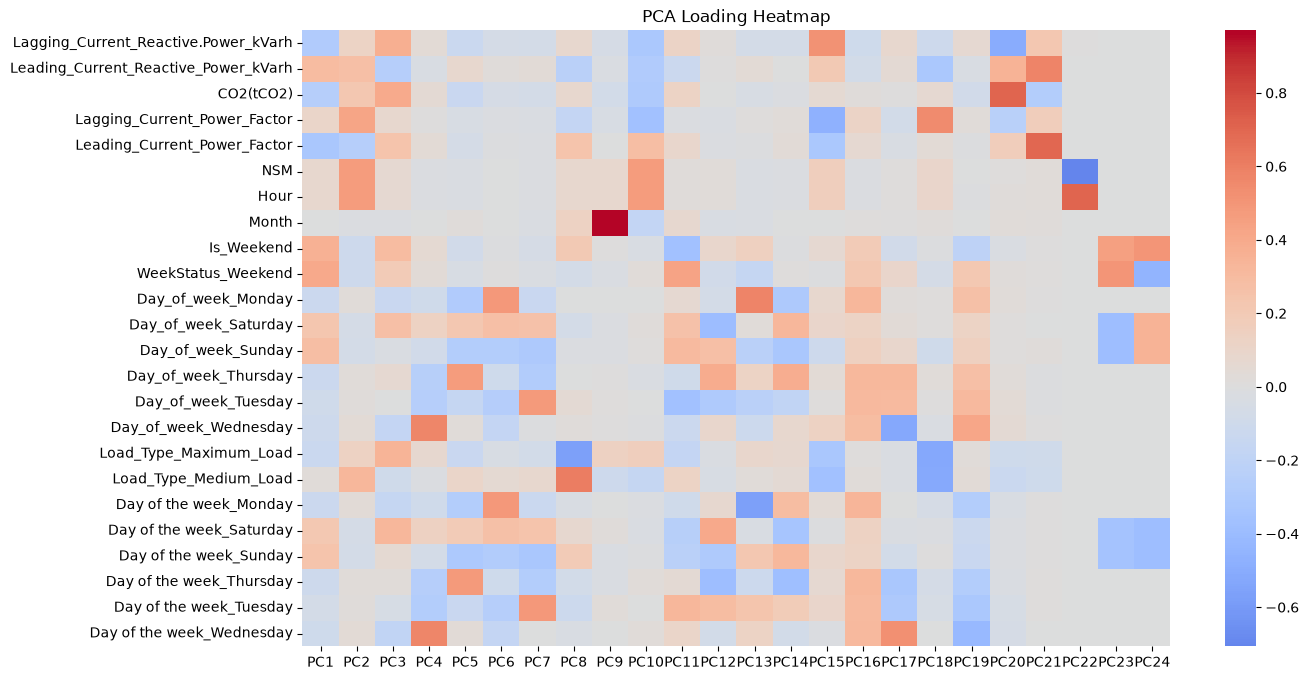

In [11]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[
        f"PC{i+1}" for i in range(pca.n_components_)
    ],
    index=X.columns
)

plt.figure(figsize=(14,8))

sns.heatmap(
    loadings,
    cmap="coolwarm",
    center=0
)

plt.title("PCA Loading Heatmap")

plt.show()

### Observation

The loading heatmap reveals that different principal components are influenced by different combinations of original features. This demonstrates how PCA transforms correlated variables into new independent components while preserving the most significant information.

# 10. PCA Summary

Principal Component Analysis successfully reduced the dimensionality of the engineered dataset while preserving most of its information. The explained variance analysis showed that a relatively small number of principal components retained approximately 95% of the total variance.

Comparing the Random Forest models demonstrated the effect of dimensionality reduction on predictive performance. Using only three principal components substantially simplified the feature space but may reduce predictive accuracy due to information loss. In contrast, using the number of components required to retain approximately 95% of the variance provided a better balance between dimensionality reduction and model performance.

Overall, PCA proved to be an effective preprocessing technique for simplifying the dataset while maintaining most of the information needed for accurate energy consumption prediction.

# Week 3 – Part 2: Flask Dashboard Deployment

## Objective

The objective of this part is to deploy the best-performing machine learning model developed in Week 2 using the Flask web framework. Instead of interacting with the model through a Jupyter Notebook, users will access it through a simple web application.

The application will include a welcome page, a dashboard displaying visualizations created during exploratory data analysis, and a prediction page where users can enter feature values to estimate energy consumption. The trained machine learning pipeline will be loaded using Joblib to ensure that the same preprocessing steps used during training are applied during prediction.

## 1. Setting Up the Flask Project

The Flask project structure is created to separate the application logic, HTML templates, and static resources such as images. This organization follows standard Flask development practices and improves maintainability.